# Baseline: hierarkisk multi-head CNN (nivå 1 + nivå 2)

Denne notebooken trener og evaluerer en enkel, hierarkisk baseline for multiattributt kjøretøygjenkjenning. Oppsettet bruker ferdige `train/val/test`-splitter, bygger et todelt labelhierarki og trener én delt CNN-backbone med to output-hoder:

- **Nivå 1 (`lvl1`)**: `Tesla` vs `Other`
- **Nivå 2 (`lvl2`)**: Tesla-underklasser, kun aktiv for bilder som faktisk tilhører `Tesla`

Notebooken dekker hele løpet fra innlesing av datasplitt og preprocessing til trening, valg av beste epoch på valideringssettet og lysstratifisert evaluering på nivå 1 og nivå 2.


### Imports og maskinvareoppsett

Importerer bibliotekene som brukes videre i notebooken og gjør et enkelt GPU-oppsett for TensorFlow. XLA slås av, og dersom en GPU er tilgjengelig settes `memory_growth` for å redusere risikoen for at TensorFlow reserverer all videominne ved oppstart.

In [1]:
# 0) Imports
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
tf.config.optimizer.set_jit(True)

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

2026-03-12 14:08:47.667625: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 14:08:48.227797: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773320928.425442    1842 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773320928.476881    1842 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-12 14:08:48.990090: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

TF: 2.18.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### Prosjektstruktur, konstanter og datasplitt-stier

Definerer sentrale konstanter for eksperimentet, blant annet seed, inputstørrelse og batch-størrelse. Deretter lokaliseres prosjektroten automatisk ved å lete etter `datasplitt/train.csv`, og de faste filstiene til `train`, `val` og `test` settes opp.


In [2]:
# 1) Les inn datasplitt og vis info
from pathlib import Path
import numpy as np
import tensorflow as tf

# Konstanter og prosjektstruktur
SEED = 42
IMG_SIZE = (300, 300)     # Modellens inputstørrelse
SHORT_SIDE = 300          # Resize korteste side til 300 før crop
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

tf.random.set_seed(SEED)
np.random.seed(SEED)

def find_project_root(start: Path) -> Path:
    # Look upwards from current working dir until we find the split CSVs
    for p in [start, *start.parents]:
        if (p / "datasplitt" / "train.csv").exists():
            return p

    # Fallback: common locations (just in case)
    candidates = [
        Path.home() / "studier" / "DAT191" / "visual-vehicle-recognition-varying-lighting-conditions",
        Path.home() / "DAT191" / "visual-vehicle-recognition-varying-lighting-conditions",
    ]
    for p in candidates:
        if (p / "datasplitt" / "train.csv").exists():
            return p

    raise FileNotFoundError(
        "Fant ikke prosjektrot: forventet datasplitt/train.csv. "
        "Sjekk at datasplitt/ finnes og at du står i riktig repo."
    )

CWD = Path.cwd()
PROJECT_ROOT = find_project_root(CWD)

SPLIT_DIR = PROJECT_ROOT / "datasplitt"
TRAIN_CSV = SPLIT_DIR / "train.csv"
VAL_CSV   = SPLIT_DIR / "val.csv"
TEST_CSV  = SPLIT_DIR / "test.csv"

print("CWD:", CWD)
print("Project root:", PROJECT_ROOT)
print("Train CSV:", TRAIN_CSV, "exists:", TRAIN_CSV.exists())
print("Val CSV:", VAL_CSV, "exists:", VAL_CSV.exists())
print("Test CSV:", TEST_CSV, "exists:", TEST_CSV.exists())



CWD: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/notebooks
Project root: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions
Train CSV: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt/train.csv exists: True
Val CSV: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt/val.csv exists: True
Test CSV: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasplitt/test.csv exists: True


### Les inn datasplittene og kontroller grunnstrukturen

Setter `IMG_ROOT` til roten for bildematerialet, leser inn `train_df`, `val_df` og `test_df`, og viser et lite utsnitt av treningsdataene. Dette gir en tidlig kontroll av at datasplittene finnes, kan leses og inneholder forventede kolonner.

In [3]:
# 2) Last split CSV-er

# Viktig: `IMG_ROOT / <image>` må peke til en faktisk fil på disk.
# Eksempelstier i CSV kan være som: Eksternt/Tesla/... eller Egenprodusert/...
# 2) Sett IMG_ROOT (datasett-roten som 'image' er relativ til)
IMG_ROOT = PROJECT_ROOT / "datasett_src"
print("IMG_ROOT:", IMG_ROOT)
print("IMG_ROOT exists:", IMG_ROOT.exists())

if not IMG_ROOT.exists():
    raise FileNotFoundError(f"Finner ikke IMG_ROOT: {IMG_ROOT}")

train_df = pd.read_csv(TRAIN_CSV)
val_df   = pd.read_csv(VAL_CSV)
test_df  = pd.read_csv(TEST_CSV)

display(train_df.head())
print("train/val/test:", len(train_df), len(val_df), len(test_df))
print("columns:", train_df.columns.tolist())

IMG_ROOT: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src
IMG_ROOT exists: True


,color,image,lighting,model,source,year,lvl1,lvl2,strat_key
0,White,Egenprodusert/non-tesla/dark/IMG_1954.jpg,Dark,Other car,internal,NaN,Other,NaN,Other|NA|Dark
1,Black/Dark gray,Egenprodusert/Tesla/daylight/IMG_1802.jpg,Light,3 2017–2023,internal,2017–2023,Tesla,3 2017–2023,Tesla|3 2017–2023|Light
2,Light gray/Silver,Egenprodusert/Tesla/dark/IMG_3834.jpg,Dark,X,internal,2016–2020,Tesla,X,Tesla|X|Dark
3,Red,Egenprodusert/non-tesla/low-light/IMG_4576.jpg,Medium,Other car,internal,NaN,Other,NaN,Other|NA|Medium
4,Red,Eksternt/non-tesla/daylight/0476_03052.jpg,Light,Other car,external,NaN,Other,NaN,Other|NA|Light


train/val/test: 3766 807 807
columns: ['color', 'image', 'lighting', 'model', 'source', 'year', 'lvl1', 'lvl2', 'strat_key']


### Rask inspeksjon av `model`-kolonnen

Viser de vanligste verdiene i `model`-feltet og et lite sortert utvalg unike modellnavn. Dette brukes som en enkel kvalitetskontroll av råetikettene før hierarkiet bygges.

In [4]:
print(train_df["model"].astype(str).str.strip().str.lower().value_counts().head(10))
print(sorted(train_df["model"].dropna().unique())[:20])

model
other car      2170
y 2020–2024     600
3 2017–2023     241
y 2025-nå       227
x               186
3 2024–nå       172
s 2016–nå        94
s 2012–2015      76
Name: count, dtype: int64
['3 2017–2023', '3 2024–nå', 'Other car', 'S 2012–2015', 'S 2016–nå', 'X', 'Y 2020–2024', 'Y 2025-nå']


In [5]:
from pathlib import Path

def fix_image_paths(df, root_dir):
    root = Path(root_dir)
    fixed_count = 0
    missing_count = 0
    
    def find_correct_extension(row_path):
        nonlocal fixed_count, missing_count
        p = root / row_path
        
        # 1. If it already exists, we're good
        if p.exists():
            return row_path
            
        # 2. Try common alternative extensions
        # (e.g., if CSV says .jpg, try .jpeg, .JPG, .png, etc.)
        alternatives = ['.jpeg', '.jpg', '.JPG', '.JPEG', '.png']
        for ext in alternatives:
            alt_p = p.with_suffix(ext)
            if alt_p.exists():
                fixed_count += 1
                # Return the path relative to IMG_ROOT
                return str(alt_p.relative_to(root))
        
        # 3. If still not found, log it
        missing_count += 1
        return row_path

    # Apply the fix to the "image" column
    df['image'] = df['image'].apply(find_correct_extension)
    
    print(f"Correction complete!")
    print(f" - Files found as-is: {len(df) - fixed_count - missing_count}")
    print(f" - Extensions corrected: {fixed_count}")
    print(f" - Still missing (not found): {missing_count}")
    
    return df

# Apply to all your splits
train_df = fix_image_paths(train_df, IMG_ROOT)
val_df = fix_image_paths(val_df, IMG_ROOT)
test_df = fix_image_paths(test_df, IMG_ROOT)

Correction complete!
 - Files found as-is: 2335
 - Extensions corrected: 1431
 - Still missing (not found): 0
Correction complete!
 - Files found as-is: 497
 - Extensions corrected: 310
 - Still missing (not found): 0
Correction complete!
 - Files found as-is: 476
 - Extensions corrected: 331
 - Still missing (not found): 0


### Analyse av bildeforhold og forventet crop-tap

Beregner statistikk for bildeformater i hvert split, blant annet hvor mange bilder som er kvadratiske, stående eller liggende, og hvor stor andel av bildet som i teorien vil gå tapt ved crop. Dette gir grunnlag for valg av preprocessingstrategi.

In [6]:
from PIL import Image
import os
import numpy as np
import pandas as pd

def aspect_stats(df: pd.DataFrame, name: str) -> dict:
    rel = df["image"].astype(str).tolist()
    abs_paths = [str(IMG_ROOT / p) for p in rel]

    exists = [p for p in abs_paths if os.path.exists(p)]
    missing = len(abs_paths) - len(exists)

    n = square = portrait = landscape = 0
    crop_fracs = []

    for p in exists:
        try:
            with Image.open(p) as im:
                w, h = im.size
        except Exception:
            continue

        n += 1
        if h == w:
            square += 1
            crop_fracs.append(0.0)
            continue

        if h > w:
            portrait += 1
        else:
            landscape += 1

        r = max(h, w) / min(h, w)
        crop_fracs.append((r - 1.0) / r)

    if n == 0:
        return {
            "split": name,
            "total_i_csv": len(abs_paths),
            "missing_files": missing,
            "checked": 0,
            "square": 0,
            "non_square": 0,
            "portrait": 0,
            "landscape": 0,
            "avg_crop_%": np.nan,
            "p50_crop_%": np.nan,
            "p90_crop_%": np.nan,
            "max_crop_%": np.nan,
        }

    cf = np.array(crop_fracs, dtype=float)
    return {
        "split": name,
        "total_i_csv": len(abs_paths),
        "missing_files": missing,
        "checked": n,
        "square": square,
        "non_square": n - square,
        "portrait": portrait,
        "landscape": landscape,
        "avg_crop_%": float(cf.mean() * 100.0),
        "p50_crop_%": float(np.quantile(cf, 0.50) * 100.0),
        "p90_crop_%": float(np.quantile(cf, 0.90) * 100.0),
        "max_crop_%": float(cf.max() * 100.0),
    }

stats = [
    aspect_stats(train_df, "train"),
    aspect_stats(val_df, "val"),
    aspect_stats(test_df, "test"),
    aspect_stats(pd.concat([train_df, val_df, test_df], ignore_index=True), "ALL"),
]

stats_df = pd.DataFrame(stats)
print(stats_df)
stats_df

   split  total_i_csv  missing_files  checked  square  non_square  portrait  \
0  train         3766              0     3766    1444        2322       701   
1    val          807              0      807     310         497       142   
2   test          807              0      807     332         475       136   
3    ALL         5380              0     5380    2086        3294       979   

   landscape  avg_crop_%  p50_crop_%  p90_crop_%  max_crop_%  
0       1621   18.658732        25.0   37.942708   75.055679  
1        355   18.906707        25.0   38.757340   66.666667  
2        339   17.825589        25.0   37.676056   69.696970  
3       2315   18.570957        25.0   38.000000   75.055679  


,split,total_i_csv,missing_files,checked,square,non_square,portrait,landscape,avg_crop_%,p50_crop_%,p90_crop_%,max_crop_%
0,train,3766,0,3766,1444,2322,701,1621,18.658732,25.0,37.942708,75.055679
1,val,807,0,807,310,497,142,355,18.906707,25.0,38.757340,66.666667
2,test,807,0,807,332,475,136,339,17.825589,25.0,37.676056,69.696970
3,ALL,5380,0,5380,2086,3294,979,2315,18.570957,25.0,38.000000,75.055679


### Bygg og valider hierarkiske kolonner

Konstruerer de hierarkiske feltene som brukes videre i modellen:

- `lvl1`: overordnet klasse (`Tesla` eller `Other`)
- `lvl2`: underklasse for Tesla-bilder
- `w_lvl2`: sample weight som gjør at nivå 2 bare teller for Tesla-rader

Blokken er skrevet idempotent, slik at hierarkiet kan bygges opp på nytt uten å gi inkonsistente resultater.

In [7]:
# 3) Bygg/valider hierarki-kolonner (idempotent: ok om de allerede finnes)
def ensure_hierarchy(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    for c in ["image", "model", "lighting"]:
        if c not in out.columns:
            raise KeyError(f"Mangler kolonne '{c}' i split-CSV. Fant: {out.columns.tolist()}")

    out["model"] = out["model"].astype("string")
    out["lighting"] = out["lighting"].astype("string")

    # lvl1: Tesla vs Other  (matcher både "Other" og "Other car")
    model_norm = out["model"].fillna("").str.strip().str.lower()
    is_other = model_norm.str.startswith("other")
    out["lvl1"] = np.where(is_other, "Other", "Tesla")

    # lvl2: kun for Tesla, ellers NA
    out["lvl2"] = out["model"].where(out["lvl1"].eq("Tesla"), pd.NA)

    # sample weight lvl2: kun Tesla
    out["w_lvl2"] = out["lvl1"].eq("Tesla").astype(np.float32)

    return out

train_df = ensure_hierarchy(train_df)
val_df   = ensure_hierarchy(val_df)
test_df  = ensure_hierarchy(test_df)

print("lvl1 counts (train):\n", train_df["lvl1"].value_counts())
print("\nlvl2 counts (train):\n", train_df["lvl2"].value_counts().head(20))
print("\nlighting counts (train):\n", train_df["lighting"].value_counts())

lvl1 counts (train):
 lvl1
Other    2170
Tesla    1596
Name: count, dtype: int64

lvl2 counts (train):
 lvl2
Y 2020–2024    600
3 2017–2023    241
Y 2025-nå      227
X              186
3 2024–nå      172
S 2016–nå       94
S 2012–2015     76
Name: count, dtype: Int64

lighting counts (train):
 lighting
Light     2068
Medium     852
Dark       846
Name: count, dtype: Int64


### Label-encoding og sample weights

Definerer label-rommet som brukes i treningen:

- `lvl1` mappes fast til `Other=0` og `Tesla=1`
- `lvl2` bygges fra Tesla-underklassene i **treningssettet**
- `y_lvl2` får dummy-verdi `0` for `Other`, men disse radene maskeres bort via `w_lvl2=0`

Deretter legges de kodede labelkolonnene til i alle splittene.

In [8]:

# lvl1: Other=0, Tesla=1 (fast)
lvl1_map = {"Other": 0, "Tesla": 1}

# lvl2: kun Tesla-klasser (fra train)
lvl2_classes = sorted(
    train_df.loc[train_df["lvl1"].eq("Tesla"), "lvl2"]
      .astype("string")
      .dropna()
      .unique()
      .tolist()
)
lvl2_to_id = {c: i for i, c in enumerate(lvl2_classes)}
num_lvl2 = len(lvl2_classes)

print("Antall lvl2-klasser:", num_lvl2)
print("Eksempel lvl2-klasser:", lvl2_classes[:10])

def add_encoded(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["y_lvl1"] = out["lvl1"].map(lvl1_map).astype(np.int32)

    # recompute weights her (Tesla=1, Other=0)
    out["w_lvl1"] = 1.0
    out["w_lvl2"] = out["lvl1"].eq("Tesla").astype(np.float32)

    # dummy 0 for Other (maskeres bort med w_lvl2=0)
    y2 = np.zeros(len(out), dtype=np.int32)
    tesla_mask = out["lvl1"].eq("Tesla").to_numpy()

    mapped = out.loc[tesla_mask, "lvl2"].map(lvl2_to_id)
    if mapped.isna().any():
        bad = out.loc[tesla_mask & mapped.isna(), "lvl2"].astype(str).unique()[:20]
        raise ValueError(f"Tesla-rader med ukjent lvl2 (ikke i train mapping): {bad}")

    y2[tesla_mask] = mapped.astype(np.int32).to_numpy()
    out["y_lvl2"] = y2

    return out

train_df = add_encoded(train_df)
val_df   = add_encoded(val_df)
test_df  = add_encoded(test_df)

display(train_df[["image","lvl1","lvl2","lighting","y_lvl1","y_lvl2","w_lvl2"]].head())

Antall lvl2-klasser: 7
Eksempel lvl2-klasser: ['3 2017–2023', '3 2024–nå', 'S 2012–2015', 'S 2016–nå', 'X', 'Y 2020–2024', 'Y 2025-nå']


,image,lvl1,lvl2,lighting,y_lvl1,y_lvl2,w_lvl2
0,Egenprodusert/non-tesla/dark/IMG_1954.jpeg,Other,<NA>,Dark,0,0,0.0
1,Egenprodusert/Tesla/daylight/IMG_1802.jpeg,Tesla,3 2017–2023,Light,1,0,1.0
2,Egenprodusert/Tesla/dark/IMG_3834.jpeg,Tesla,X,Dark,1,4,1.0
3,Egenprodusert/non-tesla/low-light/IMG_4576.jpeg,Other,<NA>,Medium,0,0,0.0
4,Eksternt/non-tesla/daylight/0476_03052.jpg,Other,<NA>,Light,0,0,0.0


### Sanity check av filstier

Et lite utvalg filstier fra treningssettet kontrolleres mot disk. Dette er en enkel verifikasjon av at `IMG_ROOT` og de relative bildestiene faktisk peker til eksisterende filer før `tf.data`-pipen bygges.


In [9]:
sample_paths = [str(IMG_ROOT / p) for p in train_df["image"].astype(str).head(10)]
exists = [Path(p).exists() for p in sample_paths]
for p, e in zip(sample_paths, exists):
    print(e, p)

True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/non-tesla/dark/IMG_1954.jpeg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/daylight/IMG_1802.jpeg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/dark/IMG_3834.jpeg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/non-tesla/low-light/IMG_4576.jpeg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Eksternt/non-tesla/daylight/0476_03052.jpg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/Tesla/dark/IMG_3856.jpeg
True /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/datasett_src/Egenprodusert/non-tesla/low-light/20260303_123840547_iOS.jpg
True /mnt/d/skole/dat191/visual-v

### Bildepreprosessering og `tf.data`-pipeline

Definerer selve inputpipen som brukes i trening og evaluering. Bildene leses fra disk, dekodes, normaliseres og standardiseres til fast inputstørrelse. For å håndtere ulike bildeforhold brukes en hybridstrategi der stående bilder center-croppes etter resize, mens liggende bilder behandles med en kombinasjon av delvis crop og reflect-padding for å bevare mer av motivet.

In [10]:

def _center_crop_after_resize_short_side(img: tf.Tensor, target: int) -> tf.Tensor:
    """Bevar aspect ratio, skaler slik at KORTESTE side = target, så center-crop til target x target."""
    shape = tf.shape(img)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)

    scale = tf.cast(target, tf.float32) / tf.minimum(h, w)
    new_h = tf.cast(tf.math.ceil(h * scale), tf.int32)
    new_w = tf.cast(tf.math.ceil(w * scale), tf.int32)

    img = tf.image.resize(img, [new_h, new_w], antialias=True, method="bilinear")
    img = tf.image.resize_with_crop_or_pad(img, target, target)  # center-crop (evt. pad hvis helt nødvendig)
    return img

def _hybrid_crop_reflect_landscape(
    img: tf.Tensor,
    target: int,
    crop_fraction_of_excess: float = 0.5,
) -> tf.Tensor:
    """
    Landscape hybrid:
    1) Skaler slik at høyden = target
    2) Crop bort en andel av overskuddsbredden
    3) Reskaler deretter hele bildet slik at bredden = target
    4) Reflect-pad høyden opp til target
    """

    shape = tf.shape(img)
    h = tf.cast(shape[0], tf.float32)
    w = tf.cast(shape[1], tf.float32)

    # Steg 1: skaler slik at høyden blir target
    scale = tf.cast(target, tf.float32) / h
    new_h = tf.cast(target, tf.int32)
    new_w = tf.cast(tf.math.ceil(w * scale), tf.int32)
    new_w = tf.maximum(new_w, 1)

    img = tf.image.resize(img, [new_h, new_w], antialias=True, method="bilinear")

    # Steg 2: crop bort en andel av overskuddsbredden
    excess_w = tf.maximum(new_w - target, 0)

    crop_total = tf.cast(
        tf.round(tf.cast(excess_w, tf.float32) * crop_fraction_of_excess),
        tf.int32
    )

    crop_left = crop_total // 2
    crop_right = crop_total - crop_left

    img = tf.cond(
        crop_total > 0,
        lambda: img[:, crop_left:new_w - crop_right, :],
        lambda: img
    )

    # Oppdater shape etter crop
    cropped_shape = tf.shape(img)
    cropped_h = cropped_shape[0]
    cropped_w = cropped_shape[1]

    # Steg 3: reskaler hele bildet slik at bredden blir target
    # Da blir høyden < target, og vi kan letterbox/reflect-padde vertikalt
    scale2 = tf.cast(target, tf.float32) / tf.cast(cropped_w, tf.float32)
    resized_h = tf.cast(tf.math.round(tf.cast(cropped_h, tf.float32) * scale2), tf.int32)
    resized_h = tf.maximum(resized_h, 1)

    img = tf.image.resize(img, [resized_h, target], antialias=True, method="bilinear")

    # Steg 4: reflect-pad høyden opp til target
    pad_h = target - resized_h
    top = pad_h // 2
    bottom = pad_h - top

    can_reflect = tf.logical_and(top < resized_h, bottom < resized_h)

    img = tf.cond(
        pad_h > 0,
        lambda: tf.cond(
            can_reflect,
            lambda: tf.pad(img, [[top, bottom], [0, 0], [0, 0]], mode="REFLECT"),
            lambda: tf.pad(img, [[top, bottom], [0, 0], [0, 0]], mode="CONSTANT", constant_values=0.0),
        ),
        lambda: img
    )

    return img

def decode_and_preprocess(path: tf.Tensor, training: bool) -> tf.Tensor:
    target = IMG_SIZE[0]  # 300
    img_bytes = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img_bytes, channels=3)
    # img = tf.image.convert_image_dtype(img, tf.float32)  # [0,1]

    shape = tf.shape(img)
    h = shape[0]
    w = shape[1]

    # Portrait eller square -> crop-løype. Landscape -> letterbox-løype.
    img = tf.cond(
    h >= w,
    lambda: _center_crop_after_resize_short_side(img, target),
    lambda: _hybrid_crop_reflect_landscape(img, target, crop_fraction_of_excess=0.5), 
    )

    img = tf.ensure_shape(img, [target, target, 3])
    return img

def make_dataset(df: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = np.array([str(IMG_ROOT / p) for p in df["image"].astype(str).to_list()], dtype=np.str_)
    y1 = df["y_lvl1"].to_numpy(np.int32)
    y2 = df["y_lvl2"].to_numpy(np.int32)
    w1 = df["w_lvl1"].to_numpy(np.float32)
    w2 = df["w_lvl2"].to_numpy(np.float32)

    ds = tf.data.Dataset.from_tensor_slices((paths, y1, y2, w1, w2))
    if training:
        ds = ds.shuffle(buffer_size=min(len(df), 5000), seed=SEED, reshuffle_each_iteration=True)

    def _map(path, y1, y2, w1, w2):
        img = decode_and_preprocess(path, training=training)
        y = {"lvl1": y1, "lvl2": y2}
        sw = {"lvl1": w1, "lvl2": w2}   # lvl2 maskeres for Other via w2=0
        return img, y, sw

    ds = ds.map(_map, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = make_dataset(train_df, training=True)
val_ds   = make_dataset(val_df, training=False)
test_ds  = make_dataset(test_df, training=False)

for x, y, sw in train_ds.take(1):
    print("x:", x.shape, x.dtype)
    print("y lvl1:", y["lvl1"].shape, "y lvl2:", y["lvl2"].shape)
    print("sw lvl1:", sw["lvl1"].shape, "sw lvl2:", sw["lvl2"].shape)


I0000 00:00:1773321022.897810    1842 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9569 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


x: (32, 300, 300, 3) <dtype: 'float32'>
y lvl1: (32,) y lvl2: (32,)
sw lvl1: (32,) sw lvl2: (32,)


2026-03-12 14:10:25.770864: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


### Visualiser et utvalg preprocessede treningsbilder

Hjelpefunksjon som kan brukes til å inspisere de første bildene i en dataset-pipeline, sammen med tilhørende labels. Dette er nyttig for å verifisere at preprocessing, labelkobling og maskering ser rimelige ut før trening.

2026-03-12 14:10:26.667490: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: cHRM: invalid chromaticities
2026-03-12 14:10:26.916903: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


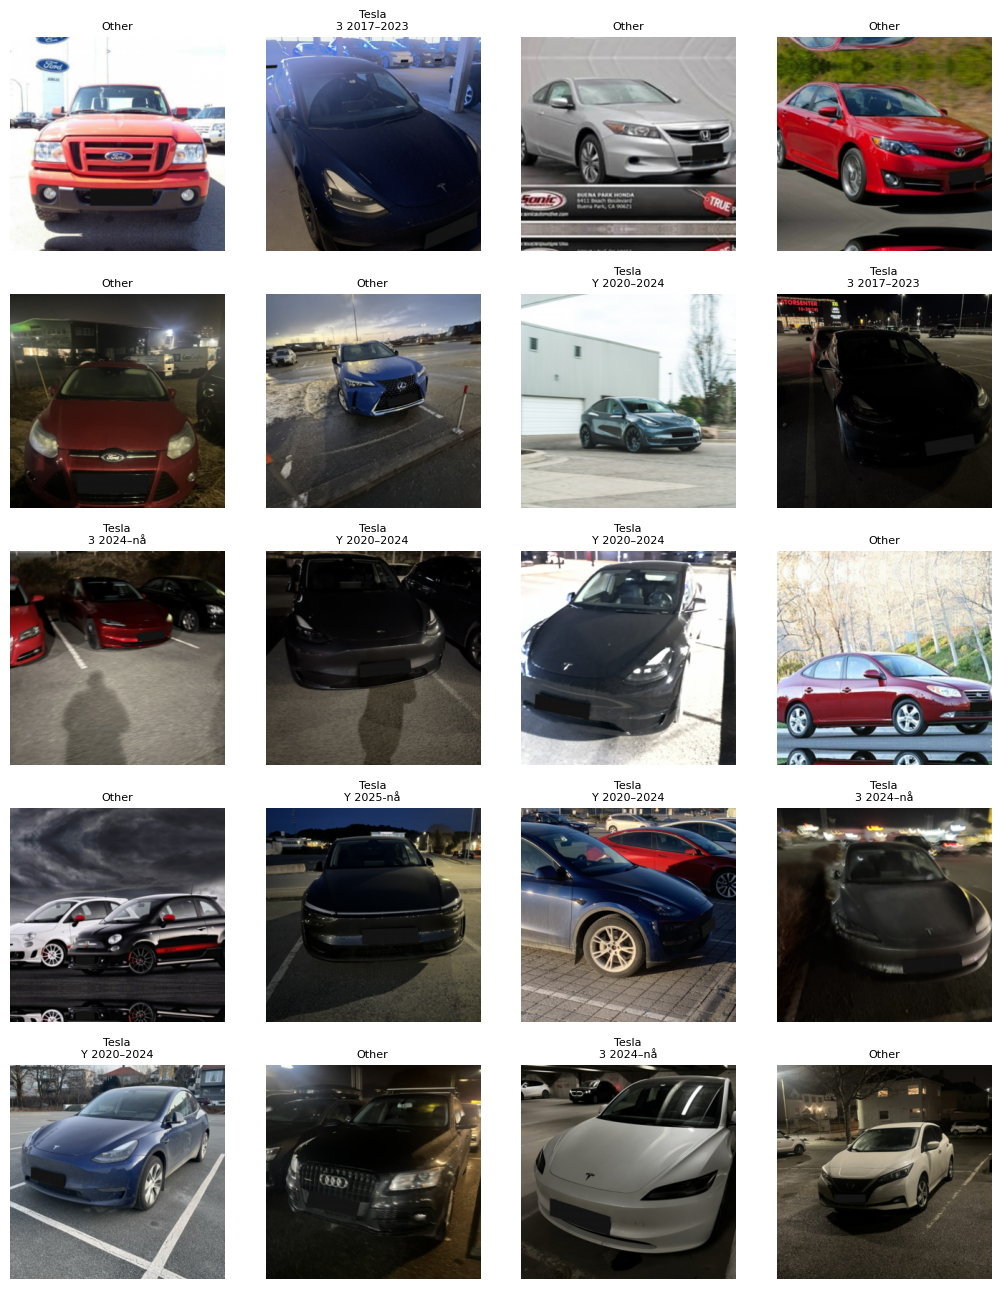

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

def show_first_images(ds, n=20, rows=5, cols=4, figsize_scale=2.6, show_titles=True):
    ds = ds.unbatch()
    plt.figure(figsize=(cols*figsize_scale, rows*figsize_scale))

    # Hvis du har disse fra før i notebooken:
    # lvl1_map = {"Other": 0, "Tesla": 1}
    # lvl2_classes = [...]
    inv_lvl1 = {v: k for k, v in lvl1_map.items()}  # 0->Other, 1->Tesla

    for i, elem in enumerate(ds.take(n)):
        # elem kan være (img, y) eller (img, y, sw)
        if isinstance(elem, tuple) and len(elem) == 3:
            img, y, sw = elem
        elif isinstance(elem, tuple) and len(elem) == 2:
            img, y = elem
            sw = None
        else:
            img = elem
            y = None
            sw = None
        img = img /255.0
        ax = plt.subplot(rows, cols, i + 1)

        im = img.numpy()
        if im.dtype != np.uint8:
            im = np.clip(im, 0.0, 1.0)
            im = (im * 255).astype(np.uint8)
        ax.imshow(im)
        ax.axis("off")

        if show_titles and isinstance(y, dict):
            y1 = int(y["lvl1"].numpy())
            title = inv_lvl1.get(y1, str(y1))

            # lvl2 kun meningsfull for Tesla (og maskeres for Other via sw["lvl2"]=0)
            if y1 == 1:  # Tesla
                y2 = int(y["lvl2"].numpy())
                lvl2_name = lvl2_classes[y2] if 0 <= y2 < len(lvl2_classes) else str(y2)
                title = f"{title}\n{lvl2_name}"

            ax.set_title(title, fontsize=8)

    plt.tight_layout()
    plt.show()

show_first_images(train_ds, n=20, rows=5, cols=4)

## Modell og logging

De neste blokkene setter opp eksperimentlogging og definerer selve baseline-modellen som skal trenes.

### AIM-logging

Oppretter et unikt eksperimentnavn og konfigurerer `AimCallback` slik at treningskurver og metrikkserier logges til prosjektets `.aim`-repo. Dette brukes senere til å inspisere `loss` og `accuracy` over epoker i AIM.

In [12]:
from aim.tensorflow import AimCallback
import datetime

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
EXPERIMENT_NAME = f"baseline_hcnn_{RUN_ID}"

aim_callback = AimCallback(
    repo=str(PROJECT_ROOT),                 # -> legger .aim i prosjektroten
    experiment=EXPERIMENT_NAME,
    log_system_params=False,                
)

print("Aim repo:", PROJECT_ROOT / ".aim")
print("Aim experiment:", EXPERIMENT_NAME)

Aim repo: /mnt/d/skole/dat191/visual-vehicle-recognition-varying-lighting-conditions/.aim
Aim experiment: baseline_hcnn_20260312-141032


### Bygg baseline-modellen

Oppretter modellen via `build_model()` og skriver ut et sammendrag av arkitekturen. Fordi modellen er pakket inn i en funksjon, kan samme arkitektur bygges opp igjen senere når lagrede checkpoints skal evalueres og beste epoch skal velges.

In [13]:
from keras import layers

def build_model():
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomRotation(0.05, seed=SEED),
        layers.RandomZoom(0.1, seed=SEED),
        layers.RandomContrast(0.2, seed=SEED),
        layers.RandomBrightness(factor=0.2, seed=SEED)
    ])

    input = x = keras.Input(shape=(*IMG_SIZE, 3))
    x = input
    x = data_augmentation(x)
    x = layers.Rescaling(1./255)(x)
    x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
    x = layers.MaxPool2D()(x)
    x = layers.Flatten()(x)
    # x = layers.Dropout(0.5)(x)


    lvl1 = layers.Dense(1, activation="sigmoid", name="lvl1")(x)
    lvl2 = layers.Dense(8, activation="softmax", name="lvl2")(x)

    return keras.Model(inputs=input, outputs={
                        "lvl1": lvl1, "lvl2": lvl2}, name="Overfitted_model")


opt = keras.optimizers.Adam(learning_rate=1e-4)


model = build_model()

model.compile(
    optimizer=opt,
    loss={
        "lvl1": keras.losses.BinaryCrossentropy(),
        "lvl2": keras.losses.SparseCategoricalCrossentropy(),
    },
    metrics={
        "lvl1": [keras.metrics.BinaryAccuracy(name="acc")],
    },
    weighted_metrics={
        "lvl2": [keras.metrics.SparseCategoricalAccuracy(name="acc")],
    },
)

model.summary()

Model: "Overfitted_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 300, 300,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential          │ (None, 300, 300,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 300, 300,  │          0 │ sequential[0][0]  │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 298, 298,  │        896 │ rescaling[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 149, 149,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 73, 73,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 71, 71,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 35, 35,    │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 156800)    │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl1 (Dense)        │ (None, 1)         │    156,801 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lvl2 (Dense)        │ (None, 8)         │  1,254,408 │ flatten[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,504,457 (5.74 MB)

 Trainable params: 1,504,457 (5.74 MB)

 Non-trainable params: 0 (0.00 B)

## Kompilering og trening

Modellen kompileres inne i `build_model()`-funksjonen, og den påfølgende treningsblokken bruker dette oppsettet sammen med checkpoint-lagring per epoch. Treningen gjennomføres uten early stopping; i stedet velges beste epoch eksplisitt senere på valideringssettet.

### Modellarkitektur og kompilering

Denne blokken bygger den hierarkiske baseline-modellen i én gjenbrukbar funksjon. Arkitekturen består av to konvolusjonsblokker med `Conv2D + MaxPooling`, etterfulgt av `Flatten` og to separate output-hoder:

- `lvl1`: binær klassifisering med sigmoid
- `lvl2`: flerklasseklassifisering med softmax

Funksjonen kompilerer også modellen med `Adam(6e-4)`, `binary_crossentropy` for nivå 1 og `sparse_categorical_crossentropy` for nivå 2. Accuracy logges separat per nivå.

### Trening med checkpoint per epoch

Trener modellen i et fast antall epoker og lagrer vekter for **hver** epoch under `checkpoints/<RUN_TAG>/`. AIM brukes som treningslogger, og den siste modellen evalueres kort på valideringssettet etter `fit()`. Denne evalueringen gjelder fortsatt siste epoch, ikke nødvendigvis beste epoch.


In [14]:
# 10) Train
EPOCHS = 40
from pathlib import Path

RUN_TAG = "baseline"
ckpt_dir = Path("checkpoints") / RUN_TAG
ckpt_dir.mkdir(parents=True, exist_ok=True)

checkpoint_callback = keras.callbacks.ModelCheckpoint(
    filepath=str(ckpt_dir / "epoch_{epoch:02d}.weights.h5"),
    save_weights_only=True,
    save_best_only=False,   # vi vil kunne evaluere alle epoker i etterkant
    verbose=0
)

callbacks = [
    aim_callback,
    checkpoint_callback,
    # evt. EarlyStopping(...)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("Eval (val; lvl2 maskert via sample_weight) – siste epoch, ikke beste:")
print(model.evaluate(val_ds, return_dict=True))

# FINAL Eval på test skal ikke kjøres her.
# Den skal først kjøres etter at beste epoch er valgt på valideringssettet.

Epoch 1/40


I0000 00:00:1773321034.416868    2858 service.cc:148] XLA service 0x7a9de02036f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773321034.418965    2858 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 3080, Compute Capability 8.6
2026-03-12 14:10:34.750024: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1773321034.959745    2858 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1773321035.626602    2858 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


 94/118 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - loss: 1.4497 - lvl1_acc: 0.5741 - lvl1_loss: 0.6697 - lvl2_acc: 0.3686 - lvl2_loss: 0.7800

2026-03-12 14:10:58.426995: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: cHRM: invalid chromaticities


118/118 ━━━━━━━━━━━━━━━━━━━━ 39s 259ms/step - loss: 1.3869 - lvl1_acc: 0.6314 - lvl1_loss: 0.6408 - lvl2_acc: 0.3684 - lvl2_loss: 0.7460 - val_loss: 1.2948 - val_lvl1_acc: 0.7038 - val_lvl1_loss: 0.5961 - val_lvl2_acc: 0.3684 - val_lvl2_loss: 0.7044
Epoch 2/40
 25/118 ━━━━━━━━━━━━━━━━━━━━ 17s 190ms/step - loss: 1.3197 - lvl1_acc: 0.7227 - lvl1_loss: 0.5939 - lvl2_acc: 0.4040 - lvl2_loss: 0.7258

...

118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 251ms/step - loss: 0.4649 - lvl1_acc: 0.8787 - lvl1_loss: 0.2883 - lvl2_acc: 0.8672 - lvl2_loss: 0.1766 - val_loss: 1.4311 - val_lvl1_acc: 0.7695 - val_lvl1_loss: 0.5470 - val_lvl2_acc: 0.4269 - val_lvl2_loss: 0.8957
Epoch 39/40
 62/118 ━━━━━━━━━━━━━━━━━━━━ 11s 208ms/step - loss: 0.4209 - lvl1_acc: 0.8928 - lvl1_loss: 0.2605 - lvl2_acc: 0.8689 - lvl2_loss: 0.1604

2026-03-12 14:29:24.841539: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: cHRM: invalid chromaticities


118/118 ━━━━━━━━━━━━━━━━━━━━ 30s 250ms/step - loss: 0.4455 - lvl1_acc: 0.8879 - lvl1_loss: 0.2799 - lvl2_acc: 0.8734 - lvl2_loss: 0.1660 - val_loss: 1.4034 - val_lvl1_acc: 0.7906 - val_lvl1_loss: 0.5119 - val_lvl2_acc: 0.4444 - val_lvl2_loss: 0.8952
Epoch 40/40
 54/118 ━━━━━━━━━━━━━━━━━━━━ 13s 213ms/step - loss: 0.4238 - lvl1_acc: 0.8969 - lvl1_loss: 0.2727 - lvl2_acc: 0.8554 - lvl2_loss: 0.1511

2026-03-12 14:29:52.983980: W tensorflow/core/lib/png/png_io.cc:89] PNG warning: cHRM: invalid chromaticities


118/118 ━━━━━━━━━━━━━━━━━━━━ 31s 257ms/step - loss: 0.4361 - lvl1_acc: 0.8903 - lvl1_loss: 0.2675 - lvl2_acc: 0.8634 - lvl2_loss: 0.1684 - val_loss: 1.3773 - val_lvl1_acc: 0.8017 - val_lvl1_loss: 0.4881 - val_lvl2_acc: 0.4357 - val_lvl2_loss: 0.8870
Eval (val; lvl2 maskert via sample_weight) – siste epoch, ikke beste:
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 207ms/step - loss: 1.3773 - lvl1_acc: 0.8017 - lvl1_loss: 0.4881 - lvl2_acc: 0.4357 - lvl2_loss: 0.8870
{'loss': 1.3772902488708496, 'lvl1_acc': 0.8017348051071167, 'lvl1_loss': 0.48806869983673096, 'lvl2_acc': 0.4356725215911865, 'lvl2_loss': 0.8870217204093933}


## Valideringsbasert epoch-valg og sluttevaluering

Etter trening settes hvilken datasplitt som skal brukes til modellvalg og evaluering. Videre defineres hjelpefunksjoner for nivå 1 og nivå 2, før alle lagrede checkpoints sammenlignes på valideringssettet for å velge én beste epoch. Til slutt kjøres og lagres de endelige nivå 1- og nivå 2-evalueringene for den valgte modellen.

### Velg evalueringssplit

Setter hvilken split som skal brukes i den videre evalueringen. Under modellutvikling brukes normalt `val`, mens samme blokker senere kan kjøres på `test` for endelig rapportering.

In [15]:
EVAL_SPLIT = "val"   # Bruk "val" for epoch-valg og modellutvikling. Bytt til "test" kun for endelig evaluering.
RUN_TAG = "baseline" # Endre per modellvariant hvis du vil lagre separate resultater.

eval_df = {"train": train_df, "val": val_df, "test": test_df}[EVAL_SPLIT].copy()
print("Evaluerer split:", EVAL_SPLIT, "n=", len(eval_df))

Evaluerer split: val n= 807


### Hjelpefunksjoner for nivå 1-evaluering

Definerer funksjoner for prediksjon og evaluering av `lvl1`. Blokken beregner metrikkene både for **Total** og per lyskategori, og returnerer også 2×2-forvirringsmatriser som senere brukes i visualisering og lagring.

In [16]:

from sklearn.metrics import (
    confusion_matrix, accuracy_score, f1_score
)

def make_x_dataset(df):
    ds = make_dataset(df, training=False)   # deterministisk preprocess
    return ds.map(lambda x, y, sw: x)       # -> x

def predict_heads(model, df):
    x_ds = make_x_dataset(df)
    preds = model.predict(x_ds, verbose=0)
    p1 = preds["lvl1"].reshape(-1)          # sigmoid
    p2 = preds["lvl2"]                      # softmax
    return p1, p2

def plot_cm_2x2(cm, title, save_path=None, ax=None):
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(3.6, 3.0))
        created_fig = True

    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([0, 1]); ax.set_xticklabels(["Other", "Tesla"])
    ax.set_yticks([0, 1]); ax.set_yticklabels(["Other", "Tesla"])
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center")
    ax.set_xlabel("Pred")
    ax.set_ylabel("True")

    if created_fig and save_path:
        plt.tight_layout()
        plt.savefig(save_path, dpi=160)
        plt.show()

def _lvl1_metrics_row(name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # [[TN FP],[FN TP]]
    tn, fp, fn, tp = cm.ravel()

    tpr = tp / (tp + fn) if (tp + fn) else np.nan
    tnr = tn / (tn + fp) if (tn + fp) else np.nan

    row = {
        "lighting": name,
        "n_total": int(len(y_true)),
        "n_other": int((y_true == 0).sum()),
        "n_tesla": int((y_true == 1).sum()),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "TPR": tpr,
        "TNR": tnr,
        "lvl1_bal_acc": (tpr + tnr) / 2 if np.isfinite(tpr) and np.isfinite(tnr) else np.nan,
        "lvl1_acc": accuracy_score(y_true, y_pred),
        "lvl1_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl1_maj_acc": max(int((y_true == 0).sum()), int((y_true == 1).sum())) / len(y_true),
    }
    return row, cm

def eval_lvl1_by_lighting(model, df, lighting_col="lighting", threshold=0.5, lighting_order=("Light", "Medium", "Dark")):
    rows = []
    cms = {}

    p1_all, _ = predict_heads(model, df)
    y_true_all = df["y_lvl1"].to_numpy().astype(int)
    y_pred_all = (p1_all >= threshold).astype(int)

    total_row, total_cm = _lvl1_metrics_row("Total", y_true_all, y_pred_all)
    rows.append(total_row)
    cms["Total"] = total_cm

    for light in lighting_order:
        mask = (df[lighting_col].to_numpy() == light)
        if not mask.any():
            continue

        y_true = y_true_all[mask]
        y_pred = y_pred_all[mask]

        row, cm = _lvl1_metrics_row(light, y_true, y_pred)
        rows.append(row)
        cms[light] = cm

    return pd.DataFrame(rows), cms

### Hjelpefunksjoner for nivå 2-evaluering

Definerer tilsvarende evalueringslogikk for `lvl2`, men kun på Tesla-rader. Her beregnes totalmetrikker, metrikk per lyskategori, klassevise precision/recall/F1-verdier og normaliserte forvirringsmatriser for videre analyse.

In [17]:
from sklearn.metrics import (
    confusion_matrix, accuracy_score, balanced_accuracy_score,
    f1_score, precision_recall_fscore_support
)

def plot_cm_norm(cm_norm, labels, title, save_path=None, max_classes=30):
    plt.figure(figsize=(7.0, 6.0))
    plt.imshow(cm_norm, interpolation="nearest")
    plt.title(title)
    plt.xticks(range(len(labels)), labels, rotation=90)
    plt.yticks(range(len(labels)), labels)
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.xlabel("Pred")
    plt.ylabel("True")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=160)
    plt.show()

def _lvl2_metrics_row(name, y_true, y_pred):
    counts = np.bincount(y_true, minlength=num_lvl2)
    maj_acc = counts.max() / len(y_true) if len(y_true) else np.nan

    row = {
        "lighting": name,
        "n_tesla": int(len(y_true)),
        "lvl2_acc": accuracy_score(y_true, y_pred),
        "lvl2_bal_acc": balanced_accuracy_score(y_true, y_pred),
        "lvl2_f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "lvl2_maj_acc": maj_acc,
    }

    cm = confusion_matrix(y_true, y_pred, labels=list(range(num_lvl2)))
    with np.errstate(divide="ignore", invalid="ignore"):
        cm_norm = cm / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)

    return row, cm, cm_norm

def eval_lvl2(model, df, lighting_col="lighting", lighting_order=("Light", "Medium", "Dark"), topn=8):
    tesla_df = df[df["y_lvl1"].astype(int) == 1].copy()
    if tesla_df.empty:
        raise ValueError("Ingen Tesla-rader i eval_df – kan ikke evaluere lvl2.")

    preds = model.predict(make_x_dataset(tesla_df), verbose=0)
    p2 = preds["lvl2"]

    y_true = tesla_df["y_lvl2"].to_numpy().astype(int)
    y_pred = np.argmax(p2, axis=1).astype(int)

    total_row, cm, cm_norm = _lvl2_metrics_row("Total", y_true, y_pred)
    df_overall = pd.DataFrame([{
        "n_tesla": total_row["n_tesla"],
        "lvl2_acc": total_row["lvl2_acc"],
        "lvl2_bal_acc": total_row["lvl2_bal_acc"],
        "lvl2_f1_macro": total_row["lvl2_f1_macro"],
        "lvl2_maj_acc": total_row["lvl2_maj_acc"],
    }])

    rows = [total_row]
    cm_norm_by_light = {"Total": cm_norm}

    for light in lighting_order:
        mask = (tesla_df[lighting_col].to_numpy() == light)
        if mask.sum() == 0:
            continue

        y_t = y_true[mask]
        y_p = y_pred[mask]

        row, _, cm_l_norm = _lvl2_metrics_row(light, y_t, y_p)
        rows.append(row)
        cm_norm_by_light[light] = cm_l_norm

    df_by_light = pd.DataFrame(rows)

    support_tbl = (
        tesla_df.groupby(["lvl2", lighting_col]).size()
        .unstack(lighting_col, fill_value=0)
        .reindex(index=lvl2_classes, fill_value=0)
    )
    support_tbl["Total"] = support_tbl.sum(axis=1)
    support_tbl.loc["Total"] = support_tbl.sum(axis=0)

    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=list(range(num_lvl2)), zero_division=0
    )
    df_per_class = pd.DataFrame({
        "class_id": range(num_lvl2),
        "class": lvl2_classes,
        "support": sup,
        "precision": prec,
        "recall": rec,
        "f1": f1,
    }).sort_values(["recall", "support"], ascending=[True, True])

    confusions = []
    for i in range(num_lvl2):
        row = cm_norm[i].copy()
        row[i] = 0.0
        j = int(np.argmax(row))
        if row[j] > 0:
            confusions.append((lvl2_classes[i], lvl2_classes[j], float(row[j]), int(cm[i].sum())))

    df_confusions = (
        pd.DataFrame(confusions, columns=["true", "pred", "rate", "support_true"])
        .sort_values(["rate", "support_true"], ascending=[False, False])
        .head(5)
    )

    return df_overall, df_by_light, support_tbl, df_per_class, cm_norm, df_confusions, cm_norm_by_light

### Velg beste epoch fra valideringssettet

Laster inn alle lagrede checkpoints, evaluerer dem på valgt split og rangerer epokene etter en samlet score:

- `0.5 * lvl1_total_f1_macro`
- `0.5 * lvl2_total_f1_macro`

Den beste epoken lastes deretter inn på nytt i `model`, slik at de neste evalueringsblokkene bruker én konsistent modell.

In [18]:
import re
# Finn lagrede checkpoints fra treningen
ckpt_dir = Path("checkpoints") / RUN_TAG
ckpt_files = sorted(ckpt_dir.glob("epoch_*.weights.h5"))

if not ckpt_files:
    raise FileNotFoundError(f"Fant ingen checkpoints i {ckpt_dir}")

rows = []

for ckpt in ckpt_files:
    # Bygg samme arkitektur på nytt
    tmp_model = build_model()
    tmp_model.load_weights(str(ckpt))

    # Eval lvl1 -> hent Total F1
    df_lvl1_tmp, _ = eval_lvl1_by_lighting(tmp_model, eval_df, threshold=0.5)
    lvl1_total_f1 = float(
        df_lvl1_tmp.loc[df_lvl1_tmp["lighting"] == "Total", "lvl1_f1_macro"].iloc[0]
    )

    # Eval lvl2 -> hent Total F1
    _, df_lvl2_tmp, _, _, _, _, _ = eval_lvl2(tmp_model, eval_df)
    lvl2_total_f1 = float(
        df_lvl2_tmp.loc[df_lvl2_tmp["lighting"] == "Total", "lvl2_f1_macro"].iloc[0]
    )

    # 50/50 samlet score
    total_score = 0.5 * lvl1_total_f1 + 0.5 * lvl2_total_f1

    epoch_num = int(re.search(r"epoch_(\d+)", ckpt.name).group(1))

    rows.append({
        "epoch": epoch_num,
        "lvl1_total_f1_macro": lvl1_total_f1,
        "lvl2_total_f1_macro": lvl2_total_f1,
        "score_50_50": total_score,
        "checkpoint": str(ckpt),
    })

epoch_scores = pd.DataFrame(rows).sort_values("epoch").reset_index(drop=True)
display(epoch_scores)

best_row = epoch_scores.sort_values("score_50_50", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])
best_ckpt = best_row["checkpoint"]

print(f"Best epoch: {best_epoch}")
print(f"Best checkpoint: {best_ckpt}")
print(f"Lvl1 Total F1: {best_row['lvl1_total_f1_macro']:.4f}")
print(f"Lvl2 Total F1: {best_row['lvl2_total_f1_macro']:.4f}")
print(f"50/50 score:   {best_row['score_50_50']:.4f}")

# Last inn beste epoch i modellen som skal brukes videre
model = build_model()
model.load_weights(best_ckpt)

print(f"Modellen er nå lastet med beste epoch = {best_epoch}")

,epoch,lvl1_total_f1_macro,lvl2_total_f1_macro,score_50_50,checkpoint
0,1,0.683198,0.105442,0.394320,checkpoints/baseline/epoch_01.weights.h5
1,2,0.707726,0.105629,0.406677,checkpoints/baseline/epoch_02.weights.h5
2,3,0.699421,0.202476,0.450948,checkpoints/baseline/epoch_03.weights.h5
3,4,0.704179,0.256270,0.480224,checkpoints/baseline/epoch_04.weights.h5
4,5,0.737899,0.326960,0.532430,checkpoints/baseline/epoch_05.weights.h5
5,6,0.741963,0.329793,0.535878,checkpoints/baseline/epoch_06.weights.h5
6,7,0.712146,0.246784,0.479465,checkpoints/baseline/epoch_07.weights.h5
7,8,0.742673,0.275741,0.509207,checkpoints/baseline/epoch_08.weights.h5
8,9,0.747633,0.313537,0.530585,checkpoints/baseline/epoch_09.weights.h5
9,10,0.759628,0.308644,0.534136,checkpoints/baseline/epoch_10.weights.h5


Best epoch: 28
Best checkpoint: checkpoints/baseline/epoch_28.weights.h5
Lvl1 Total F1: 0.7989
Lvl2 Total F1: 0.4063
50/50 score:   0.6026
Modellen er nå lastet med beste epoch = 28


### Kjør og lagre nivå 1-resultater

Kjører endelig `lvl1`-evaluering for den modellen som nå er lastet inn, lagrer metrikk-tabellen til disk og produserer forvirringsmatriser for `Light`, `Medium` og `Dark`.

,lighting,n_total,n_other,n_tesla,TN,FP,FN,TP,TPR,TNR,lvl1_bal_acc,lvl1_acc,lvl1_f1_macro,lvl1_maj_acc
0,Total,807,465,342,405,60,96,246,0.719298,0.870968,0.795133,0.806691,0.798884,0.576208
1,Light,442,282,160,248,34,46,114,0.712500,0.879433,0.795966,0.819005,0.800685,0.638009
2,Medium,185,93,92,81,12,24,68,0.739130,0.870968,0.805049,0.805405,0.804440,0.502703
3,Dark,180,90,90,76,14,26,64,0.711111,0.844444,0.777778,0.777778,0.776786,0.500000


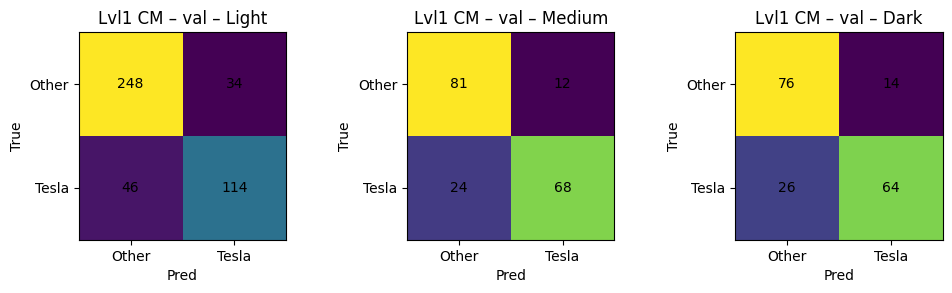

In [19]:
out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl1"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl1, cm_by_light = eval_lvl1_by_lighting(model, eval_df, threshold=0.5)
df_lvl1.to_csv(out_dir / "lvl1_metrics_by_lighting.csv", index=False, encoding="utf-8")
display(df_lvl1)

fig, axes = plt.subplots(1, 3, figsize=(10, 3.0))

for ax, light in zip(axes, ("Light", "Medium", "Dark")):
    if light in cm_by_light:
        plot_cm_2x2(cm_by_light[light], f"Lvl1 CM – {EVAL_SPLIT} – {light}", ax=ax)

fig.tight_layout()
fig.savefig(out_dir / "cm_lvl1_all.png", dpi=160)
plt.show()

### Kjør og lagre nivå 2-resultater

Kjører tilsvarende sluttevaluering for `lvl2`, lagrer metrikk per lyskategori, klassevise PR/F1-resultater og de vanligste forvekslingene, og visualiserer normaliserte forvirringsmatriser for Tesla-underklassene.

,lighting,n_tesla,lvl2_acc,lvl2_bal_acc,lvl2_f1_macro,lvl2_maj_acc
0,Total,342,0.450292,0.428407,0.406286,0.374269
1,Light,160,0.493750,0.454339,0.407879,0.362500
2,Medium,92,0.500000,0.417007,0.413878,0.380435
3,Dark,90,0.322222,0.297619,0.268799,0.388889


,class_id,class,support,precision,recall,f1
0,0,3 2017–2023,51,0.333333,0.098039,0.151515
2,2,S 2012–2015,16,0.200000,0.250000,0.222222
6,6,Y 2025-nå,49,0.436364,0.489796,0.461538
4,4,X,41,0.512195,0.512195,0.512195
5,5,Y 2020–2024,128,0.571429,0.531250,0.550607
3,3,S 2016–nå,20,0.578947,0.550000,0.564103
1,1,3 2024–nå,37,0.287671,0.567568,0.381818


,true,pred,rate,support_true
0,3 2017–2023,Y 2020–2024,0.470588,51
2,S 2012–2015,Y 2020–2024,0.312500,16
1,3 2024–nå,Y 2020–2024,0.189189,37
6,Y 2025-nå,3 2024–nå,0.183673,49
5,Y 2020–2024,3 2024–nå,0.179688,128


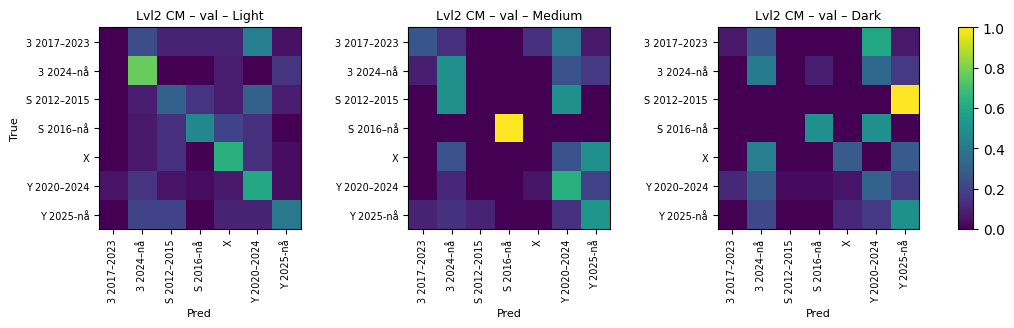

In [20]:

out_dir = Path("results") / RUN_TAG / EVAL_SPLIT / "lvl2"
out_dir.mkdir(parents=True, exist_ok=True)

df_lvl2_overall, df_lvl2_by_light, support_tbl, df_lvl2_per_class, cm_norm, df_confusions, cm_norm_by_light = eval_lvl2(model, eval_df)


df_lvl2_by_light.to_csv(out_dir / "lvl2_metrics_by_lighting.csv", index=False, encoding="utf-8")
df_lvl2_per_class.to_csv(out_dir / "lvl2_per_class_pr.csv", index=False, encoding="utf-8")
df_confusions.to_csv(out_dir / "lvl2_top_confusions.csv", index=False, encoding="utf-8")


display(df_lvl2_by_light)
display(df_lvl2_per_class.head(10))
display(df_confusions)

fig, axes = plt.subplots(1, 3, figsize=(10.2, 3.6))

for k, (ax, light) in enumerate(zip(axes, ("Light", "Medium", "Dark"))):
    if light not in cm_norm_by_light:
        ax.axis("off")
        continue

    im = ax.imshow(cm_norm_by_light[light], interpolation="nearest", vmin=0, vmax=1)
    ax.set_title(f"Lvl2 CM – {EVAL_SPLIT} – {light}", fontsize=9)

    ax.set_xticks(range(num_lvl2))
    ax.set_xticklabels(lvl2_classes, rotation=90, fontsize=7)
    ax.set_yticks(range(num_lvl2))
    ax.set_yticklabels(lvl2_classes, fontsize=7)

    ax.set_xlabel("Pred", fontsize=8)
    ax.set_ylabel("True" if k == 0 else "", fontsize=8)

fig.subplots_adjust(left=0.06, right=0.90, top=0.86, bottom=0.30, wspace=0.30)

cax = fig.add_axes([0.92, 0.30, 0.015, 0.56])
fig.colorbar(im, cax=cax)

fig.savefig(out_dir / "cm_lvl2_norm_by_lighting.png", dpi=160)
plt.show()